In [1]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

with open("processed_battery_features.pkl", "rb") as f:
    feature_df = pickle.load(f)

In [2]:
model_df = feature_df.dropna().copy()

feature_columns = [
    "DTW_I",
    "DTW_V"
]

target_column = "SOH"

features = model_df[feature_columns]
target = model_df[target_column]

In [3]:
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [4]:
model = LinearRegression()

model.fit(features_train, target_train)

target_pred = model.predict(features_test)

In [5]:
mae = mean_absolute_error(target_test, target_pred)
r2 = r2_score(target_test, target_pred)

print(f"MAE: {mae:.4f}")
print(f"R² : {r2:.4f}")

MAE: 0.0385
R² : 0.6054


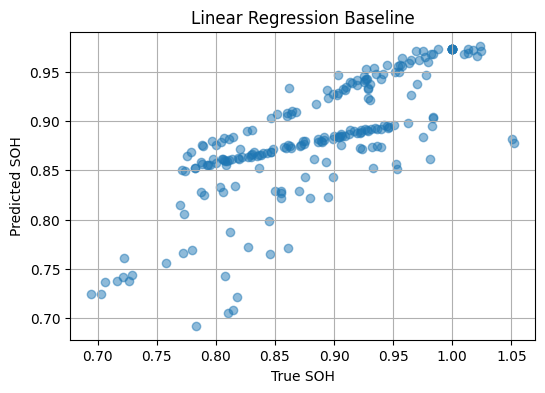

In [6]:
plt.figure(figsize=(6, 4))

plt.scatter(target_test, target_pred, alpha=0.5)

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Linear Regression Baseline")

plt.grid(True)

plt.show()